In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings

In [12]:
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv(r'D:\Users\Devang Dalvi\Desktop\finalyear_project\Cardiovascular_Disease_Dataset.csv')

In [13]:
# Display the first few rows of the dataset
print(df.head())

   patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0     103368   53       1          2        171                0   
1     119250   40       1          0         94              229   
2     119372   49       1          2        133              142   
3     132514   43       1          0        138              295   
4     146211   31       1          1        199                0   

   fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  \
0                  0                1           147              0      5.3   
1                  0                1           115              0      3.7   
2                  0                0           202              1      5.0   
3                  1                1           153              0      3.2   
4                  0                2           136              0      5.3   

   slope  noofmajorvessels  target  
0      3                 3       1  
1      1                 1       0  
2    

In [4]:
# Basic info about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB
None


In [5]:

# Check for missing values
print(df.isnull().sum())

patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64


In [6]:
# Basic statistics of the dataset
print(df.describe())

          patientid         age       gender    chestpain    restingBP  \
count  1.000000e+03  1000.00000  1000.000000  1000.000000  1000.000000   
mean   5.048704e+06    49.24200     0.765000     0.980000   151.747000   
std    2.895905e+06    17.86473     0.424211     0.953157    29.965228   
min    1.033680e+05    20.00000     0.000000     0.000000    94.000000   
25%    2.536440e+06    34.00000     1.000000     0.000000   129.000000   
50%    4.952508e+06    49.00000     1.000000     1.000000   147.000000   
75%    7.681877e+06    64.25000     1.000000     2.000000   181.000000   
max    9.990855e+06    80.00000     1.000000     3.000000   200.000000   

       serumcholestrol  fastingbloodsugar  restingrelectro  maxheartrate  \
count      1000.000000        1000.000000      1000.000000   1000.000000   
mean        311.447000           0.296000         0.748000    145.477000   
std         132.443801           0.456719         0.770123     34.190268   
min           0.000000       

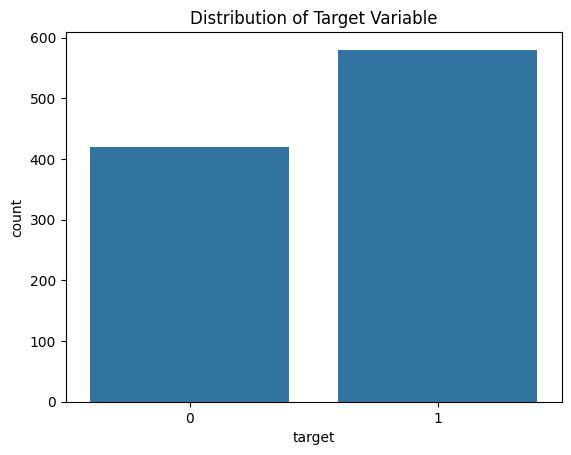

In [7]:
#eda
# Distribution of target variable
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable')
plt.show()

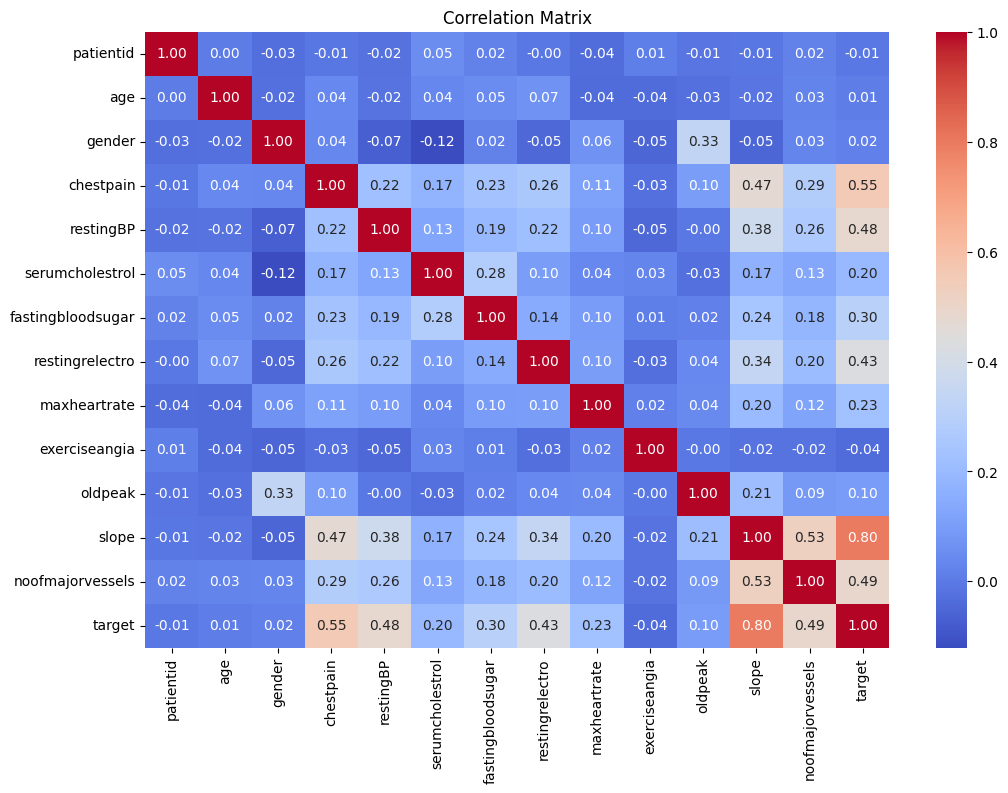

In [8]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

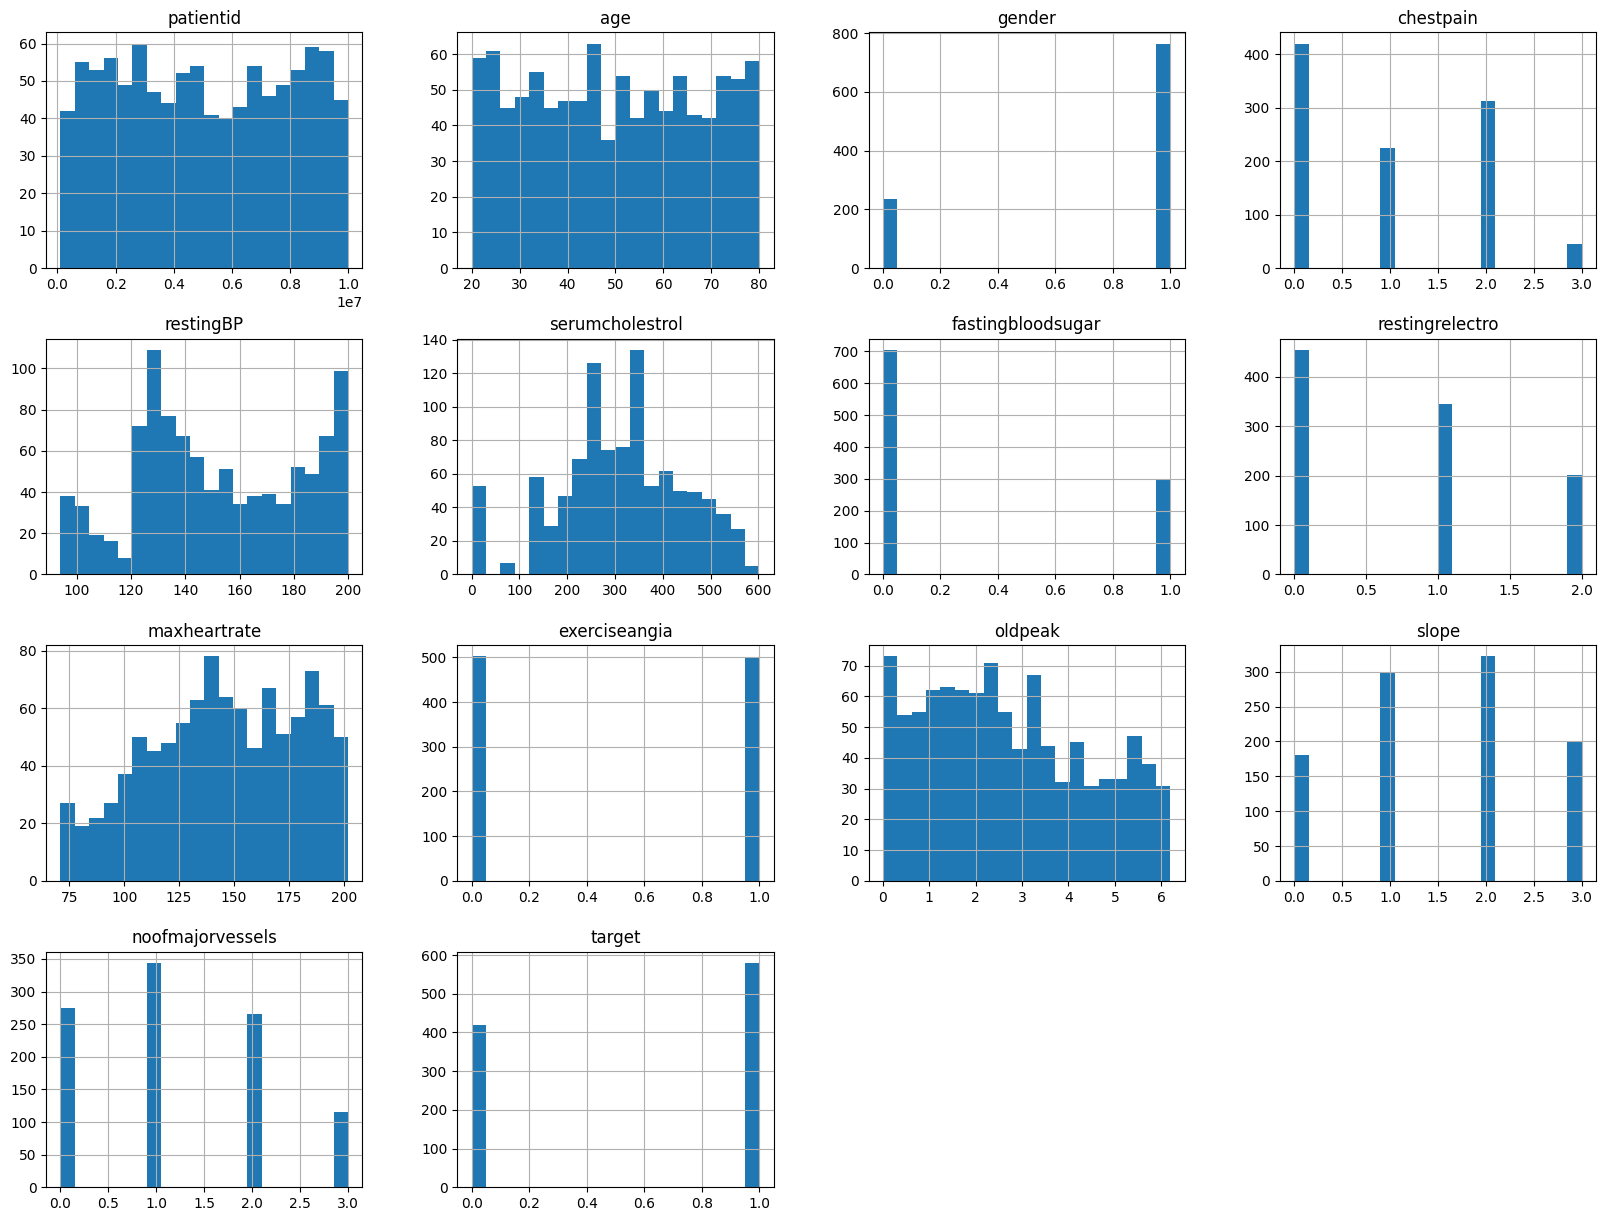

In [9]:
# Distribution of numerical features
df.hist(bins=20, figsize=(20, 15))
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
# Standardizing numerical features
#scaler = StandardScaler()
#numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
#df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [14]:
# Split the dataset into training and testing sets
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}


In [18]:
# Dictionary to store accuracies
model_accuracies = {}
model_reports = {}

In [19]:
# Train and evaluate models
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    model_accuracies[model_name] = accuracy
    model_reports[model_name] = {
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

In [20]:
# Display the results
for model_name, metrics in model_reports.items():
    print(f'{model_name} Accuracy: {model_accuracies[model_name]:.2f}')
    print(metrics['classification_report'])
    print(metrics['confusion_matrix'])
    print('-'*50)

Logistic Regression Accuracy: 0.68
              precision    recall  f1-score   support

           0       0.69      0.40      0.50        83
           1       0.67      0.87      0.76       117

    accuracy                           0.68       200
   macro avg       0.68      0.63      0.63       200
weighted avg       0.68      0.68      0.65       200

[[ 33  50]
 [ 15 102]]
--------------------------------------------------
Random Forest Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        83
           1       0.98      0.99      0.99       117

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200

[[ 81   2]
 [  1 116]]
--------------------------------------------------
Support Vector Machine Accuracy: 0.58
              precision    recall  f1-score   support

           0       0.00      0.00      0.

In [23]:
# Train and evaluate models
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    # Predict on the test set
    y_pred = model.predict(X_test)
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    model_accuracies[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

# Display model accuracies
model_accuracies

Logistic Regression Accuracy: 0.6750
Random Forest Accuracy: 0.9800
Support Vector Machine Accuracy: 0.5850
K-Nearest Neighbors Accuracy: 0.5150
Decision Tree Accuracy: 0.9650


{'Logistic Regression': 0.675,
 'Random Forest': 0.98,
 'Support Vector Machine': 0.585,
 'K-Nearest Neighbors': 0.515,
 'Decision Tree': 0.965}

Text(0.5, 1.0, 'Comparison of Model Accuracies')

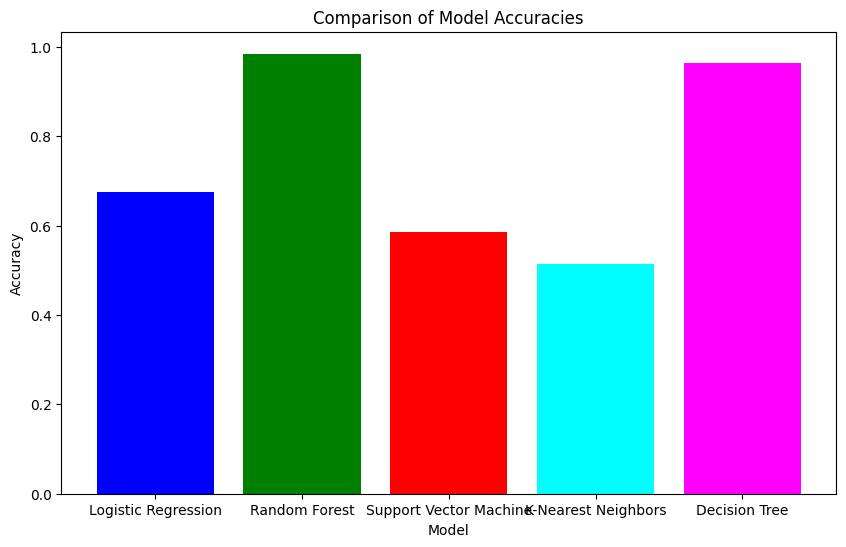

In [21]:
# Plotting the accuracies with annotations
plt.figure(figsize=(10, 6))
bars = plt.bar(model_accuracies.keys(), model_accuracies.values(), color=['blue', 'green', 'red', 'cyan', 'magenta'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')

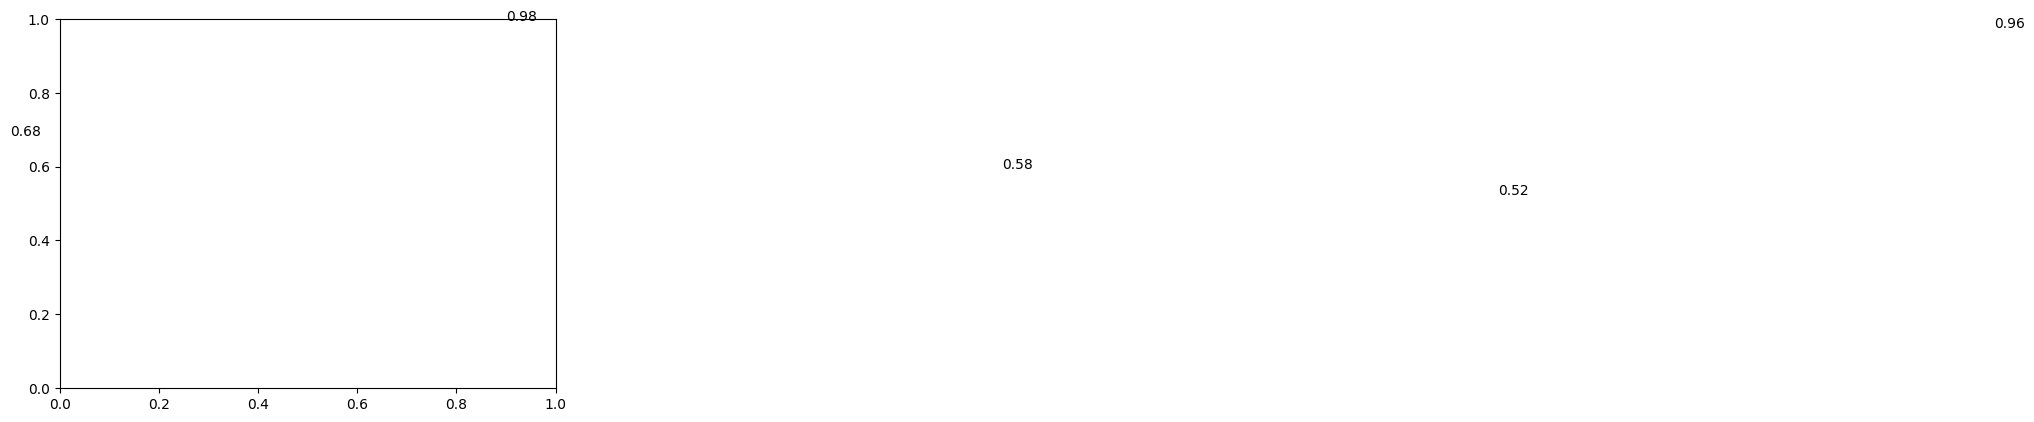

In [22]:
# Adding the annotations
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, yval + 0.01, round(yval, 2))

plt.show()

In [24]:
# Install SHAP (if needed)
! pip install shap


[notice] A new release of pip is available: 23.0.1 -> 24.2
[notice] To update, run: D:\Users\Devang Dalvi\Desktop\projectpr\mynewv\Scripts\python.exe -m pip install --upgrade pip
